# NiSpace workflows

The notebooks so far have built up the NiSpace pipeline step by step — `fit()`, `transform_y()`, `clean_y()`, `colocalize()`, `permute()`, `plot()`. That level of control is great when you need flexibility. But for standard analyses, NiSpace provides **workflow functions** that run the complete pipeline in a single call.

Three workflows are available:

| Function | Question answered | Null model |
|----------|-------------------|------------|
| `simple_colocalization()` | Does this map colocalize with reference maps? | Surrogate map permutation |
| `group_comparison()` | Do brain alterations in this group colocalize with reference maps? | Group label permutation |
| `simple_xsea()` | Is the average colocalization with a set of maps higher than expected by chance? | Surrogate map permutation |

All workflows return `(colocalizations, p_values, q_values, nsp_object)`. The `nsp_object` is a fully fitted `NiSpace` instance — you can call any of the methods you've seen in previous notebooks on it.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import pandas as pd
import numpy as np

## `simple_colocalization()` — single map

The simplest workflow: you have one (or a few) group-level brain maps and want to test whether they colocalize with a set of reference maps.

INFO | 31/05/26 13:33:10 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 31/05/26 13:33:10 | nispace.datasets: Loading pet maps.


INFO | 31/05/26 13:33:10 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 31/05/26 13:33:10 | nispace.datasets: Filtering maps by collection.


INFO | 31/05/26 13:33:10 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


...

Null colocalizations (spearman, 4 proc):  61%|████████████████████████████████████████████████████████████████████████████████████████████████████                                                               | 6136/10000 [00:00<00:00, 10817.47it/s]

Null colocalizations (spearman, 4 proc):  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 8184/10000 [00:00<00:00, 11055.58it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 11872.89it/s]

INFO | 31/05/26 13:33:36 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


INFO | 31/05/26 13:33:37 | nispace.plotting: Significance annotation: 3/29 p_uncorrected < 0.05, 0/29 p_fdrbh < 0.05


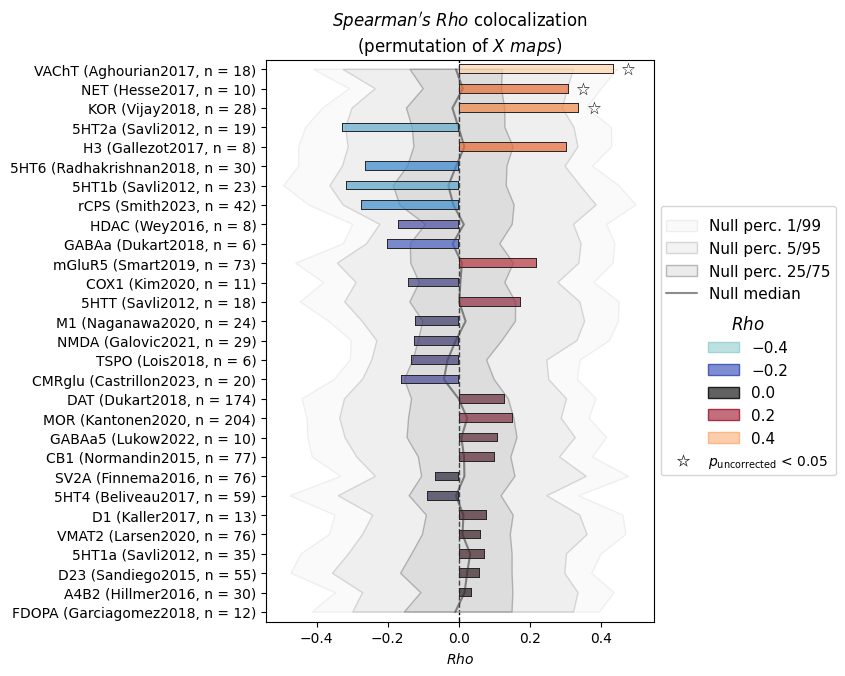

In [2]:
from nispace.workflows import simple_colocalization
from nispace.io import load_img

pain_map = load_img("neuroquery/pain.nii.gz")

colocs, p_values, q_values, nsp = simple_colocalization(
    y={"Pain": pain_map},  # dict key becomes the map label; can also be just the image
    x="pet",               # string shortcut: automatically fetches the PET reference dataset
    x_collection="UniqueTracers",
    parcellation="Schaefer200",
    colocalization_method="spearman",
    permute_kwargs={"p_tails": "upper"},  # directional test
    mc_method="fdr_bh",
    n_perm=10000,
    seed=42,
    n_proc=4
)

In [3]:
# results are standard DataFrames
results = pd.concat([colocs, p_values, q_values], keys=["rho", "p", "q"])
results.droplevel(1).T.sort_values(by="p").head(8)

,,rho,p,q
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.435971,0.0117,0.266800
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.339014,0.0184,0.266800
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.309315,0.0480,0.464000
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.304823,0.0747,0.541575
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.219451,0.1621,0.874531
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.176491,0.2272,0.874531
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.151909,0.2553,0.874531
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.129229,0.2677,0.874531


INFO | 31/05/26 13:33:39 | nispace.plotting: Significance annotation: 3/29 p_uncorrected < 0.05, 0/29 p_fdr_bh < 0.05


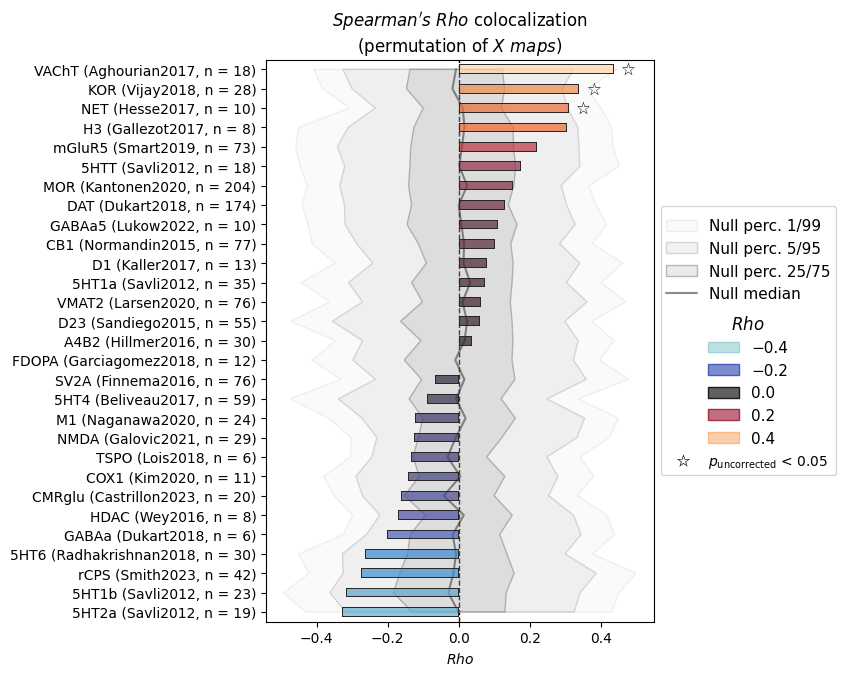

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x17fd554c0>)

In [4]:
# the nsp_object is a fully fitted NiSpace object — you can use all methods on it
nsp.plot(mc_method="fdr_bh", sort_by="coloc")

## `group_comparison()` — patient vs. control

The group comparison workflow handles the full pipeline for individual subject data: covariate regression, effect size computation, colocalization, and group label permutation.

The `design` argument is a DataFrame with one row per subject. The column `"groups"` is required; any other columns are treated as covariates to regress out. A `"site"` column triggers ComBat harmonization if `combat=True`.

We use the anorexia nervosa example dataset here.

> **Note:** This dataset is **simulated** and not intended for scientific use — it exists purely for demonstration purposes.

INFO | 31/05/26 13:33:39 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200Parcels7Networks.


INFO | 31/05/26 13:33:39 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 31/05/26 13:33:39 | nispace.datasets: Loading pet maps.


INFO | 31/05/26 13:33:39 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 31/05/26 13:33:39 | nispace.datasets: Filtering maps by collection.


...

WARNING | 31/05/26 13:33:39 | nispace.io: Parcellated data contains nan values!


INFO | 31/05/26 13:33:39 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 31/05/26 13:33:39 | nispace.workflows: DataFrame provided for design. Expecting 'groups' and, if paired==True, 'subjects' columns.


INFO | 31/05/26 13:33:39 | nispace.workflows: Design matrix of shape (100, 3). Assuming 100 subjects/maps.


INFO | 31/05/26 13:33:39 | nispace.core.clean_y: Detected categorical covariates: none; continuous: ['age', 'sex'].


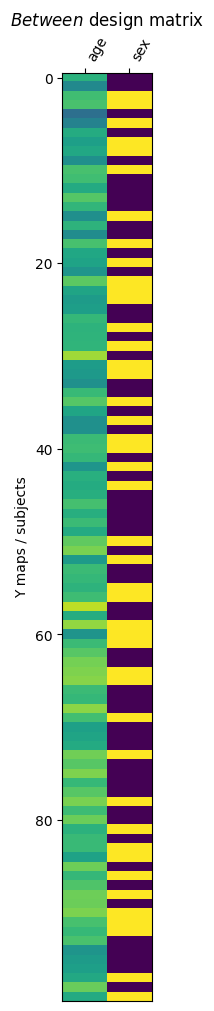

INFO | 31/05/26 13:33:39 | nispace.core.clean_y: Protecting 1 variable(s) during regression: ['groups_HC'].


INFO | 31/05/26 13:33:39 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y.


Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc):   0%|                                                                                                                                               | 0/200 [00:00<?, ?it/s]

Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc):   4%|█████▍                                                                                                                                 | 8/200 [00:02<00:50,  3.80it/s]

Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 93.20it/s]

...

Null colocalizations (spearman, 4 proc):   0%|                                                                                                                                                                                  | 0/5000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):  41%|██████████████████████████████████████████████████████████████████▉                                                                                                 | 2040/5000 [00:00<00:00, 19785.64it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 32343.19it/s]

INFO | 31/05/26 13:33:43 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


INFO | 31/05/26 13:33:43 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 7/29 p_fdrbh < 0.05


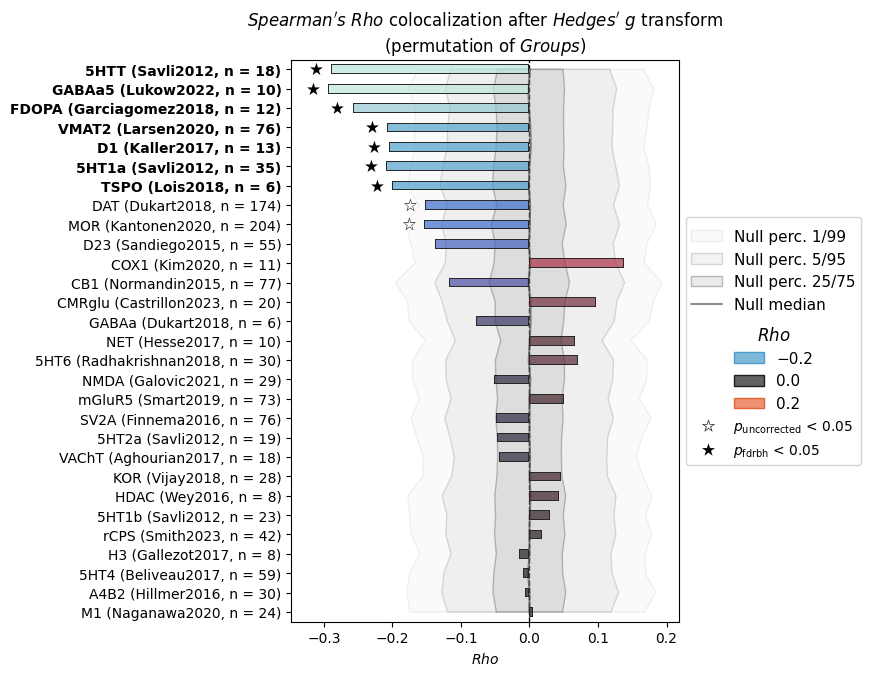

In [5]:
from nispace.workflows import group_comparison
from nispace.datasets import fetch_example

# load the anorexia nervosa example data
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")

# extract group labels
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

# generate synthetic covariates
rng = np.random.default_rng(42)
age = np.concatenate([rng.normal(25, 5, 50), rng.normal(30, 5, 50)])
sex = rng.integers(0, 2, 100)

# design matrix: groups column is mandatory, others are covariates
design = pd.DataFrame({
    "groups": groups,
    "age": age,
    "sex": sex
}, index=an_data.index)

colocs_gc, p_gc, q_gc, nsp_gc = group_comparison(
    y=an_data,
    design=design,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="Schaefer200",
    comparison_method="hedges(a,b)",
    colocalization_method="spearman",
    mc_method="fdr_bh",
    n_perm=5000,
    seed=42,
    n_proc=4
)

In [6]:
# top results
gc_results = pd.concat([colocs_gc, p_gc, q_gc], keys=["rho", "p", "q"])
gc_results.droplevel(1).T.sort_values(by="p").head(8)

,,rho,p,q
set,map,,,
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,-0.289860,0.0002,0.001933
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,-0.294028,0.0002,0.001933
Dopamine,target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-garciagomez2018,-0.258163,0.0002,0.001933
General,target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020,-0.208262,0.0028,0.020300
Serotonin,target-5HT1a_tracer-way100635_n-35_dx-hc_pub-savli2012,-0.208632,0.0044,0.023200
Dopamine,target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller2017,-0.204952,0.0048,0.023200
Immunity,target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018,-0.200293,0.0104,0.043086
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,-0.152391,0.0316,0.114550


INFO | 31/05/26 13:33:44 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 7/29 p_fdr_bh < 0.05


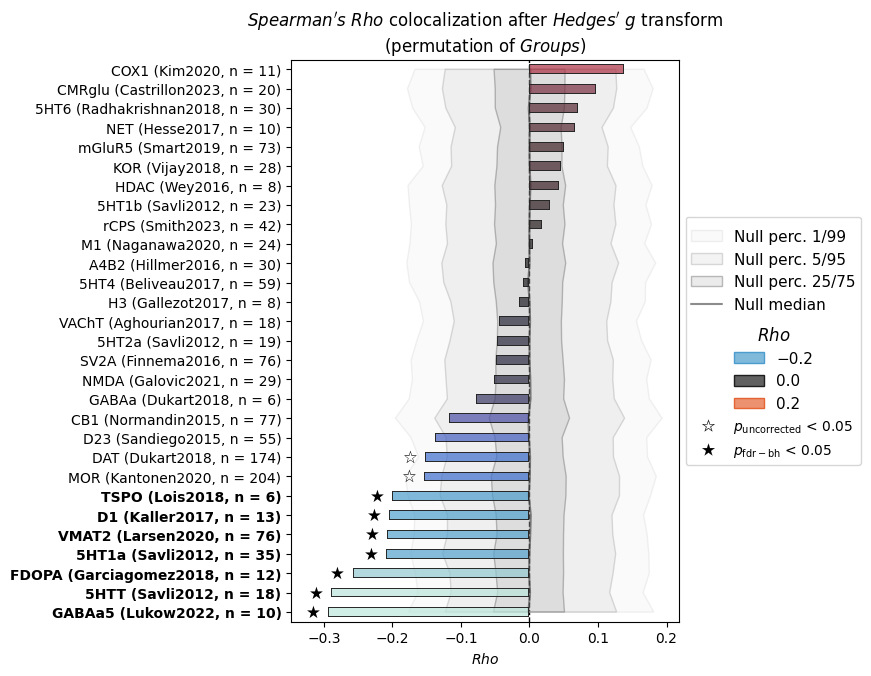

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Hedges'\\ g$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x17f054550>)

In [7]:
nsp_gc.plot(sort_by="coloc", mc_method="fdr_bh")

WARNING | 31/05/26 13:33:45 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 31/05/26 13:33:45 | nispace.plotting: brainplot: threshold='auto' → 0.001035715569742024


INFO | 31/05/26 13:33:45 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 31/05/26 13:33:45 | nispace.core.parcellation: Parcellation 'Schaefer200Parcels7Networks': active space set to 'MNI152NLin2009cAsym' (was 'fsLR').


INFO | 31/05/26 13:33:45 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


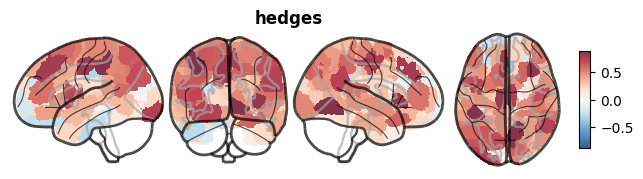

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [8]:
# effect size map on the brain
nsp_gc.plot_brain(data="Y", symmetric_cmap=True)

## `simple_xsea()` — X-Set Enrichment Analysis

XSEA tests whether the average colocalization between your input map and a *set* of reference maps is higher than expected by chance. This is useful when you have reference maps organized into biologically meaningful groups (e.g., gene expression grouped by cell type).

We'll cover XSEA in much more detail in [Notebook 10](intro10_xsea.ipynb). Here's a minimal example:

INFO | 31/05/26 13:33:48 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 31/05/26 13:33:48 | nispace.datasets: Loading mrna maps.


INFO | 31/05/26 13:33:48 | nispace.datasets: Loading integrated collection 'CellTypesSilettiSuperclusters' for dataset 'mrna'.


INFO | 31/05/26 13:33:48 | nispace.datasets: Filtering maps by collection.


INFO | 31/05/26 13:33:48 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


...

Null colocalizations (spearman, 4 proc):  92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊             | 4600/5000 [00:02<00:00, 1564.78it/s]

Null colocalizations (spearman, 4 proc):  97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏    | 4856/5000 [00:03<00:00, 1563.46it/s]

Null colocalizations (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:03<00:00, 1650.02it/s]

INFO | 31/05/26 13:33:56 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


INFO | 31/05/26 13:33:56 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_fdrbh < 0.05


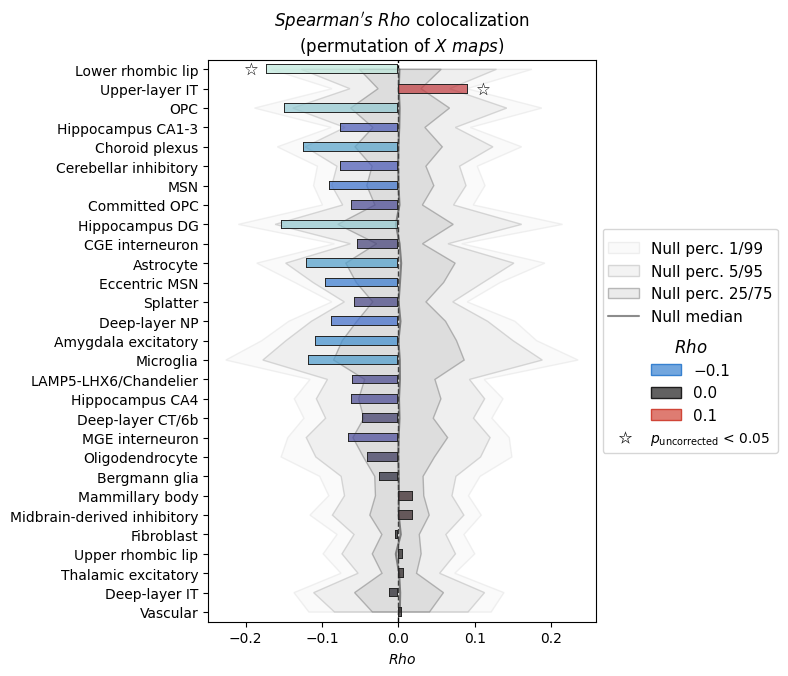

In [9]:
from nispace.workflows import simple_xsea
from nispace.datasets import fetch_reference

# use the anorexia nervosa Hedges' g map we computed above
hedges_g = nsp_gc.get_y()

# test against mRNA gene expression sets (cell type markers)
colocs_xsea, p_xsea, q_xsea, nsp_xsea = simple_xsea(
    y=hedges_g,
    x="mrna",          # mRNA gene expression reference
    x_collection="CellTypesSilettiSuperclusters",  # predefined cell type sets
    parcellation="Schaefer200",  
    colocalization_method="spearman",
    mc_method="fdr_bh",
    n_perm=5000,
    seed=42,
    n_proc=4
)

INFO | 31/05/26 13:33:57 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_fdr_bh < 0.05


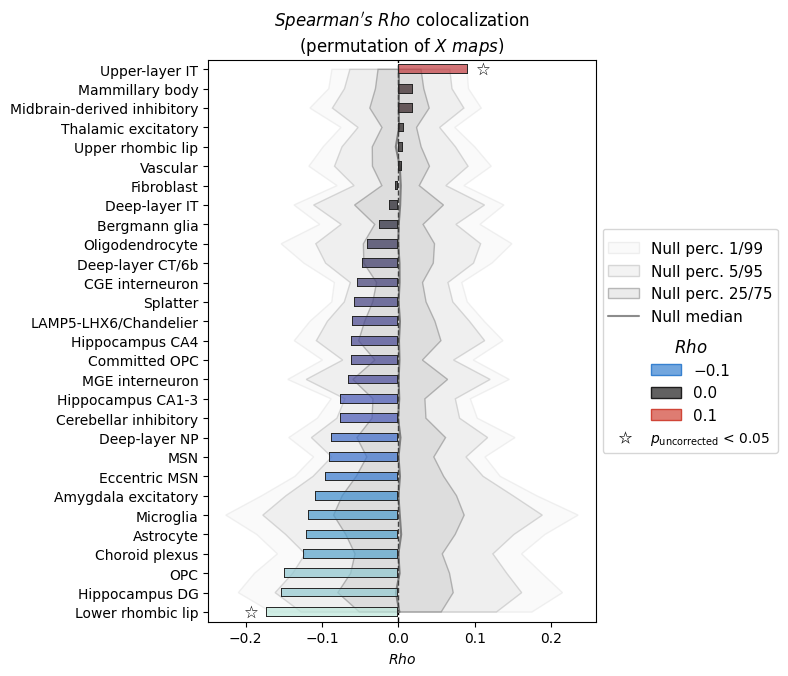

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x30d4c89a0>)

In [10]:
nsp_xsea.plot(sort_by="coloc", mc_method="fdr_bh")

## When to use workflows vs. the object API

| Situation | Recommended approach |
|-----------|---------------------|
| Quick analysis, standard pipeline | Workflow function |
| Need full control over each step | Object API (`NiSpace` class) |
| Custom preprocessing sequence | Object API |
| Running the same analysis on many maps | Object API (reuse the fitted object) |
| Embedding in a larger pipeline | Object API |
| Teaching/demonstration | Workflow (less boilerplate) |

The two approaches are not exclusive. You can start with a workflow, inspect the returned `nsp_object`, and then call additional methods on it — for example to plot with different settings, or to run additional permutation tests.

## Summary

All three workflows return `(colocalizations, p_values, q_values, nsp_object)` and accept these common arguments:

```python
simple_colocalization(y, x="pet", x_collection=None, parcellation="Schaefer200",
                      colocalization_method="spearman", mc_method="meff",
                      n_perm=10000, seed=None, n_proc=1)

group_comparison(y, design, x="pet", comparison_method="hedges(a,b)",
                 colocalization_method="spearman", mc_method="meff",
                 n_perm=10000, seed=None, n_proc=1)

simple_xsea(y, x="mrna", x_collection=None, parcellation="Schaefer200",
            colocalization_method="spearman", mc_method="meff",
            n_perm=10000, seed=None, n_proc=1)
```

Next: [Notebook 10](intro10_xsea.ipynb) dives deep into X-Set Enrichment Analysis.